In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
palette_color = sns.color_palette("pastel")

In [ ]:
df = pd.read_csv('dataset/train.csv')
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


# Data Understanding

In [106]:
df.columns.tolist()

['id',
 'Age',
 'Gender',
 'Annual Income',
 'Marital Status',
 'Number of Dependents',
 'Education Level',
 'Occupation',
 'Health Score',
 'Location',
 'Policy Type',
 'Previous Claims',
 'Vehicle Age',
 'Credit Score',
 'Insurance Duration',
 'Policy Start Date',
 'Customer Feedback',
 'Smoking Status',
 'Exercise Frequency',
 'Property Type',
 'Premium Amount']

In [107]:
df.shape

(1200000, 21)

In [108]:
df.describe().round(2)

,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1200000.00,1181295.00,1155051.00,1090328.00,1125924.00,835971.00,1199994.00,1062118.00,1199999.00,1200000.00
mean,599999.50,41.15,32745.22,2.01,25.61,1.00,9.57,592.92,5.02,1102.54
std,346410.31,13.54,32179.51,1.42,12.20,0.98,5.78,149.98,2.59,865.00
min,0.00,18.00,1.00,0.00,2.01,0.00,0.00,300.00,1.00,20.00
25%,299999.75,30.00,8001.00,1.00,15.92,0.00,5.00,468.00,3.00,514.00
50%,599999.50,41.00,23911.00,2.00,24.58,1.00,10.00,595.00,5.00,872.00
75%,899999.25,53.00,44634.00,3.00,34.53,2.00,15.00,721.00,7.00,1509.00
max,1199999.00,64.00,149997.00,4.00,58.98,9.00,19.00,849.00,9.00,4999.00


## Explore the Columns and Data Types

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

## Check for Missing Values And Duplicates

In [110]:
df.isnull().sum()

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [111]:
df.duplicated().sum()

np.int64(0)

## Numerical And Categorical Columns Split

In [112]:
target_var = 'Premium Amount'
numerical_vars = df.select_dtypes(include = ['number']).columns
categorical_vars = df.select_dtypes(include = ['object']).columns
print("Target Column:", target_var)
print( "\nNumerical Columns:", numerical_vars.tolist())
print( "\nCategorical Columns:", categorical_vars.tolist())

Target Column: Premium Amount

Numerical Columns: ['id', 'Age', 'Annual Income', 'Number of Dependents', 'Health Score', 'Previous Claims', 'Vehicle Age', 'Credit Score', 'Insurance Duration', 'Premium Amount']

Categorical Columns: ['Gender', 'Marital Status', 'Education Level', 'Occupation', 'Location', 'Policy Type', 'Policy Start Date', 'Customer Feedback', 'Smoking Status', 'Exercise Frequency', 'Property Type']


In [113]:
numerical_data = df.select_dtypes(include = ['number'])
categorical_data = df.select_dtypes(include = ['object'])

In [114]:
print ("Numerical Data Description:")
numerical_data.describe().round(2)

Numerical Data Description:


,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1200000.00,1181295.00,1155051.00,1090328.00,1125924.00,835971.00,1199994.00,1062118.00,1199999.00,1200000.00
mean,599999.50,41.15,32745.22,2.01,25.61,1.00,9.57,592.92,5.02,1102.54
std,346410.31,13.54,32179.51,1.42,12.20,0.98,5.78,149.98,2.59,865.00
min,0.00,18.00,1.00,0.00,2.01,0.00,0.00,300.00,1.00,20.00
25%,299999.75,30.00,8001.00,1.00,15.92,0.00,5.00,468.00,3.00,514.00
50%,599999.50,41.00,23911.00,2.00,24.58,1.00,10.00,595.00,5.00,872.00
75%,899999.25,53.00,44634.00,3.00,34.53,2.00,15.00,721.00,7.00,1509.00
max,1199999.00,64.00,149997.00,4.00,58.98,9.00,19.00,849.00,9.00,4999.00


In [115]:
print("Categorical Data Description:")
categorical_data.describe()

Categorical Data Description:


,Gender,Marital Status,Education Level,Occupation,Location,Policy Type,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
count,1200000,1181471,1200000,841925,1200000,1200000,1200000,1122176,1200000,1200000,1200000
unique,2,3,4,3,3,3,167381,3,2,4,3
top,Male,Single,Master's,Employed,Suburban,Premium,2020-02-08 15:21:39.134960,Average,Yes,Weekly,House
freq,602571,395391,303818,282750,401542,401846,142,377905,601873,306179,400349


## Statistical Analysis

In [116]:
for c in categorical_vars:
    col_cnt = categorical_data[c].nunique()
    print(f"{c} has {col_cnt} unique values .")

Gender has 2 unique values .
Marital Status has 3 unique values .
Education Level has 4 unique values .
Occupation has 3 unique values .
Location has 3 unique values .
Policy Type has 3 unique values .
Policy Start Date has 167381 unique values .
Customer Feedback has 3 unique values .
Smoking Status has 2 unique values .
Exercise Frequency has 4 unique values .
Property Type has 3 unique values .


In [117]:
for i in categorical_vars:
    print (f'Value Count for {i}')
    print(df[i].value_counts())
    print("\n")

Value Count for Gender
Gender
Male      602571
Female    597429
Name: count, dtype: int64


Value Count for Marital Status
Marital Status
Single      395391
Married     394316
Divorced    391764
Name: count, dtype: int64


Value Count for Education Level
Education Level
Master's       303818
PhD            303507
Bachelor's     303234
High School    289441
Name: count, dtype: int64


Value Count for Occupation
Occupation
Employed         282750
Self-Employed    282645
Unemployed       276530
Name: count, dtype: int64


Value Count for Location
Location
Suburban    401542
Rural       400947
Urban       397511
Name: count, dtype: int64


Value Count for Policy Type
Policy Type
Premium          401846
Comprehensive    399600
Basic            398554
Name: count, dtype: int64


Value Count for Policy Start Date
Policy Start Date
2020-02-08 15:21:39.134960    142
2023-08-13 15:21:39.155231    137
2022-02-02 15:21:39.134960    137
2022-08-30 15:21:39.134960    134
2023-11-02 15:21:39.134960  

# **Exploratory Data Analysis**

## Numerical features distribution

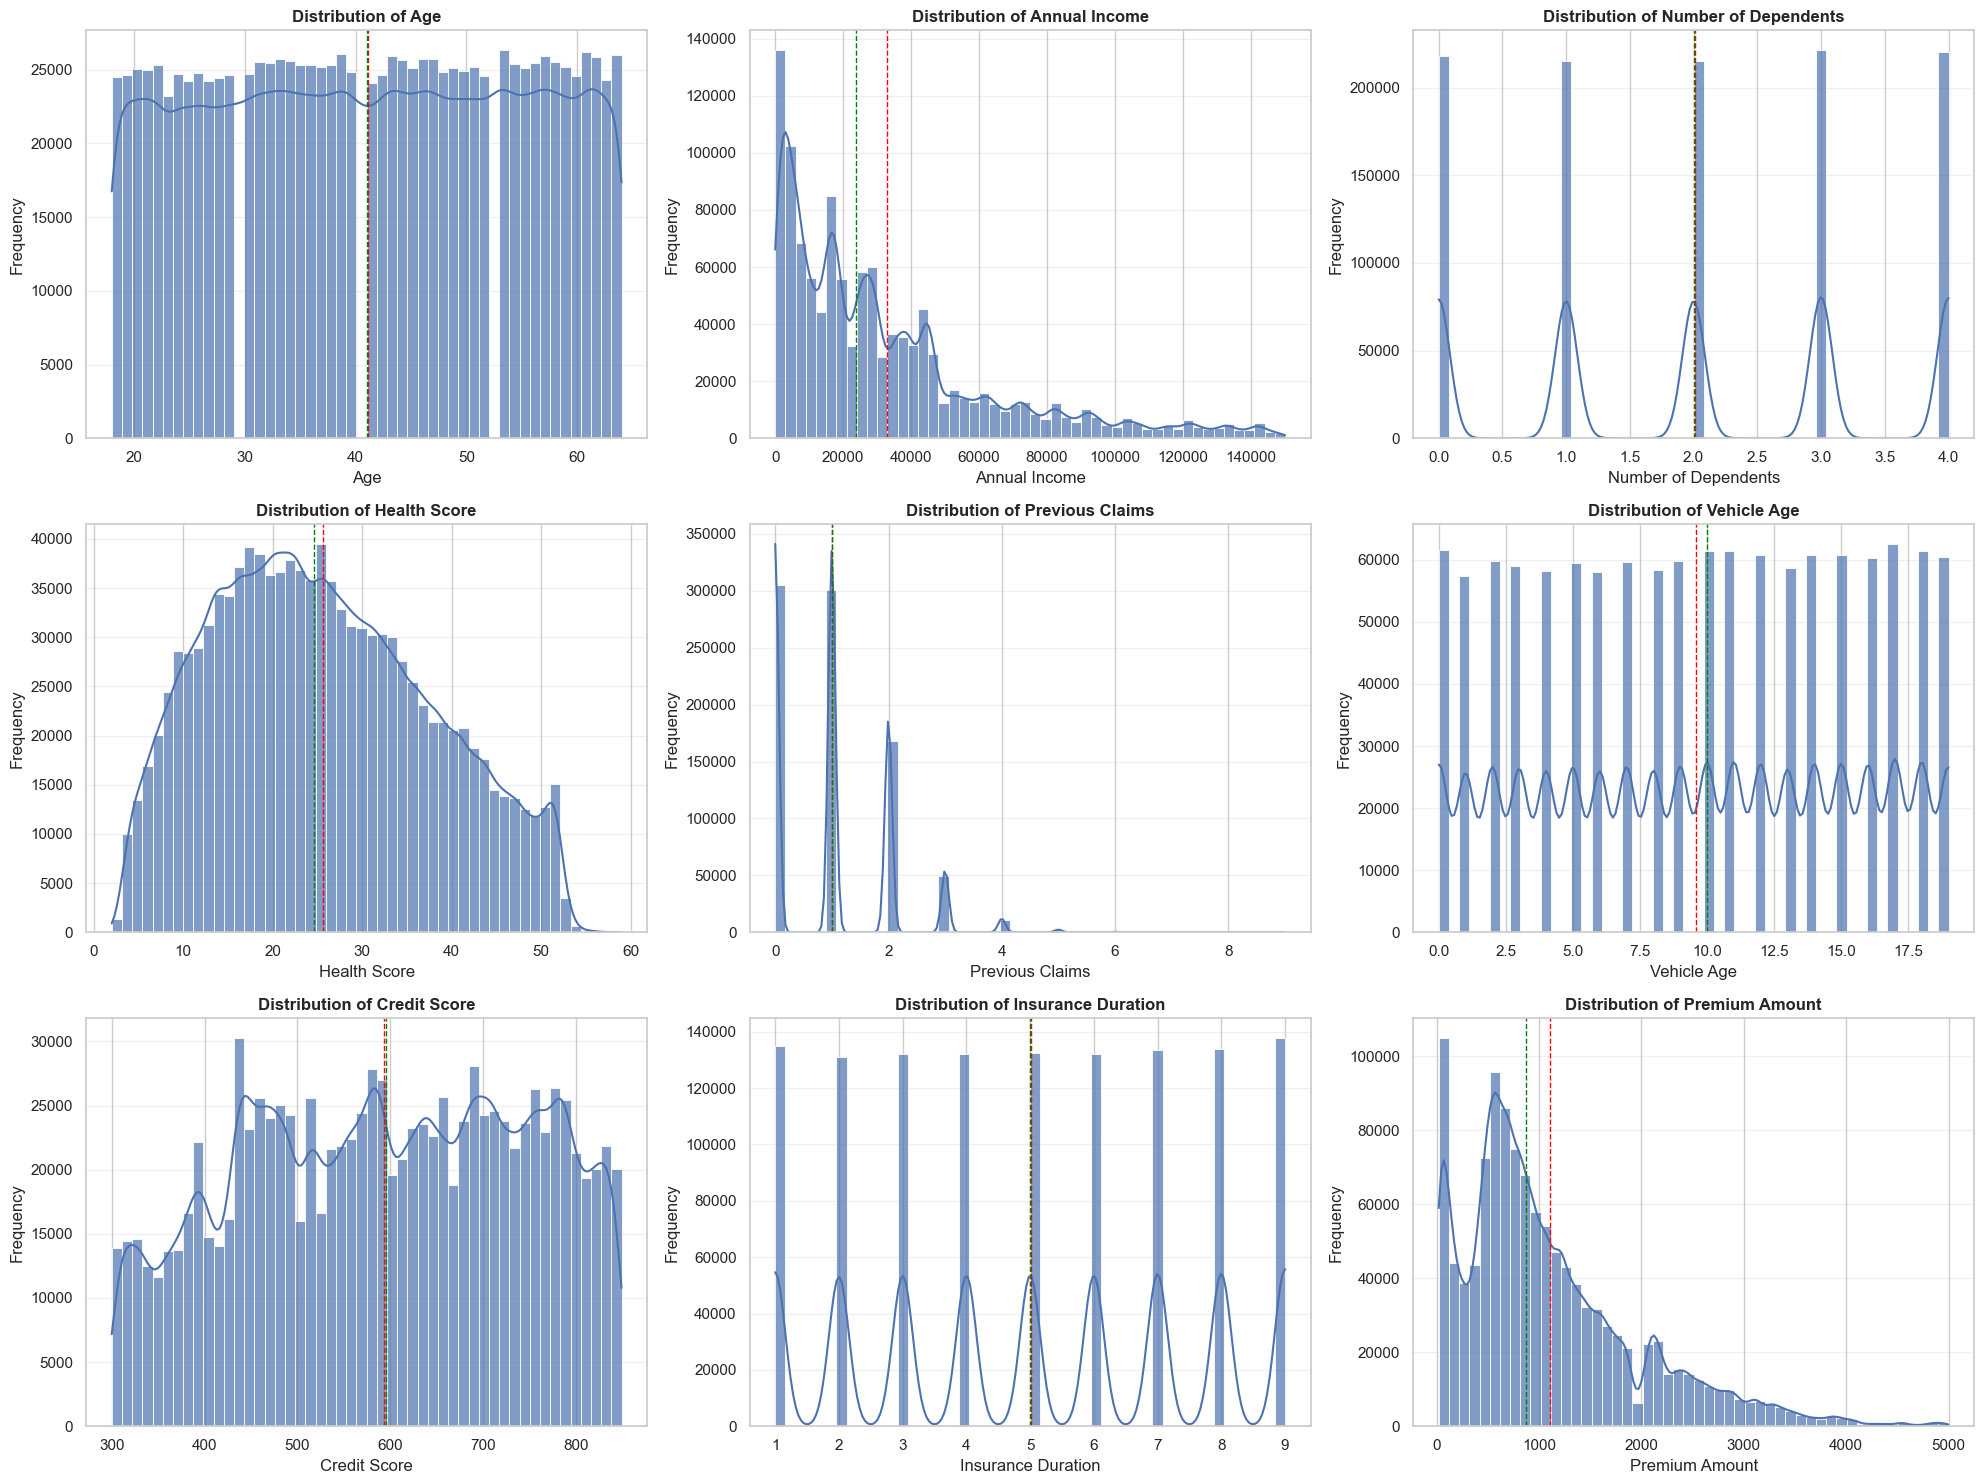

In [123]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['id'])

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.histplot(df[col].dropna(), kde=True, bins=50, ax=axes[idx], alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add mean and median lines
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=1, label=f'Median: {df[col].median():.2f}')

for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## Categorical features distribution

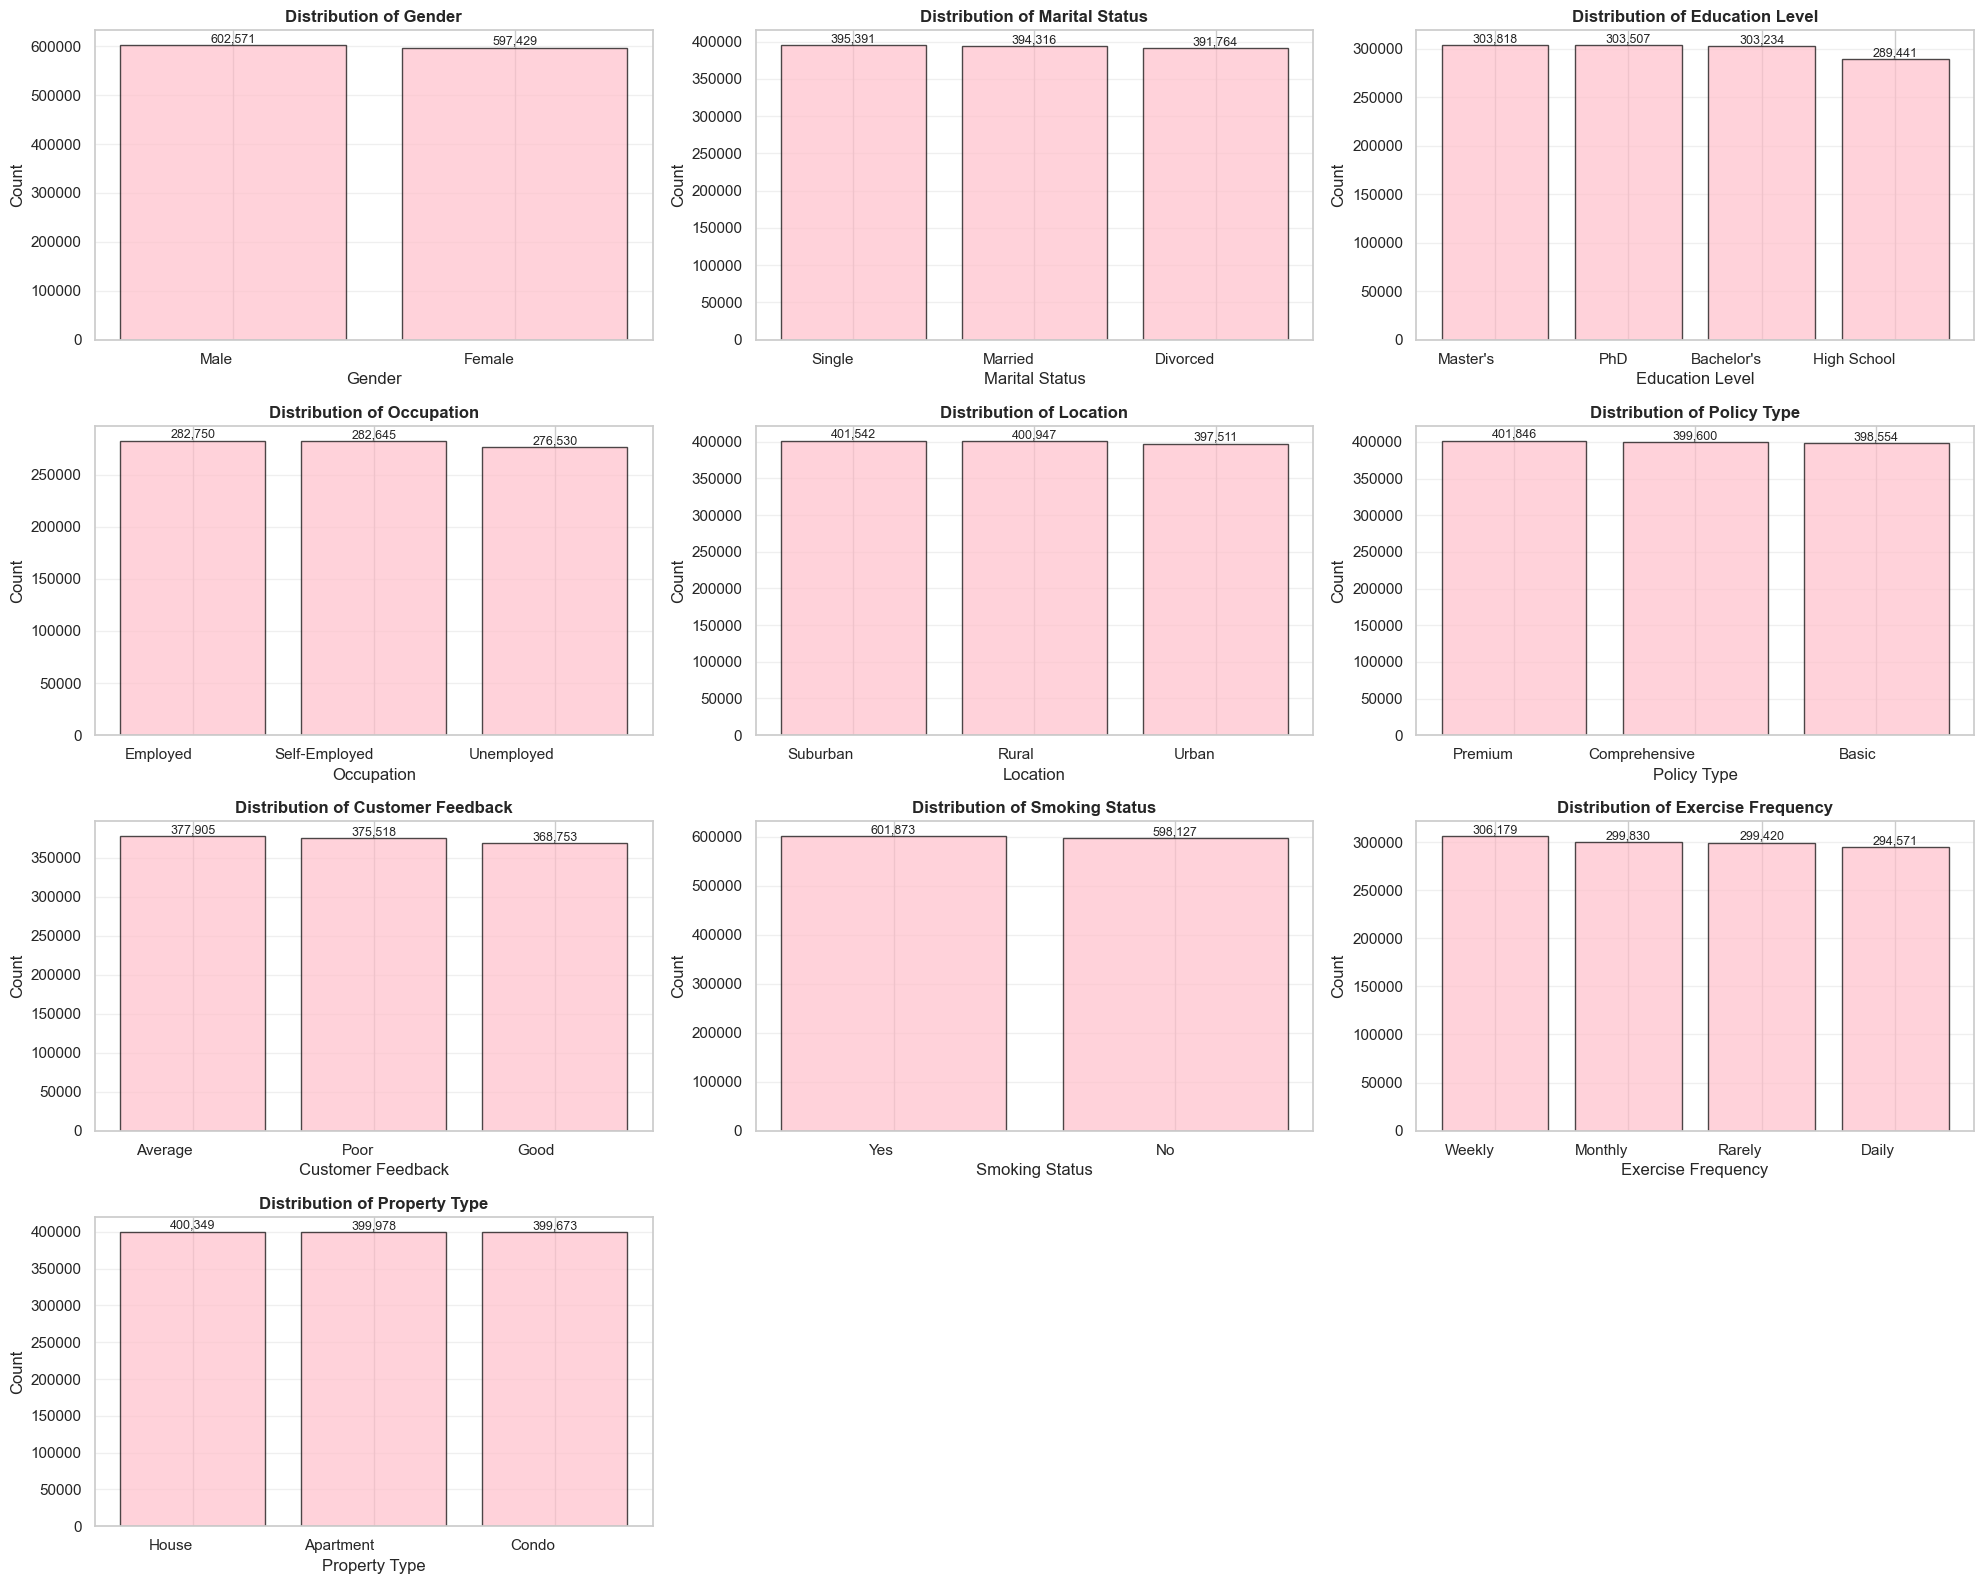

In [124]:
categorical_cols = df.select_dtypes(include=['object']).columns.drop(['Policy Start Date'])

fig, axes = plt.subplots(4, 3, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='pink', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=0, ha='right')
        axes[idx].grid(axis='y', alpha=0.3)
        
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

# Hide extra subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Numerical Features vs Premium Amount

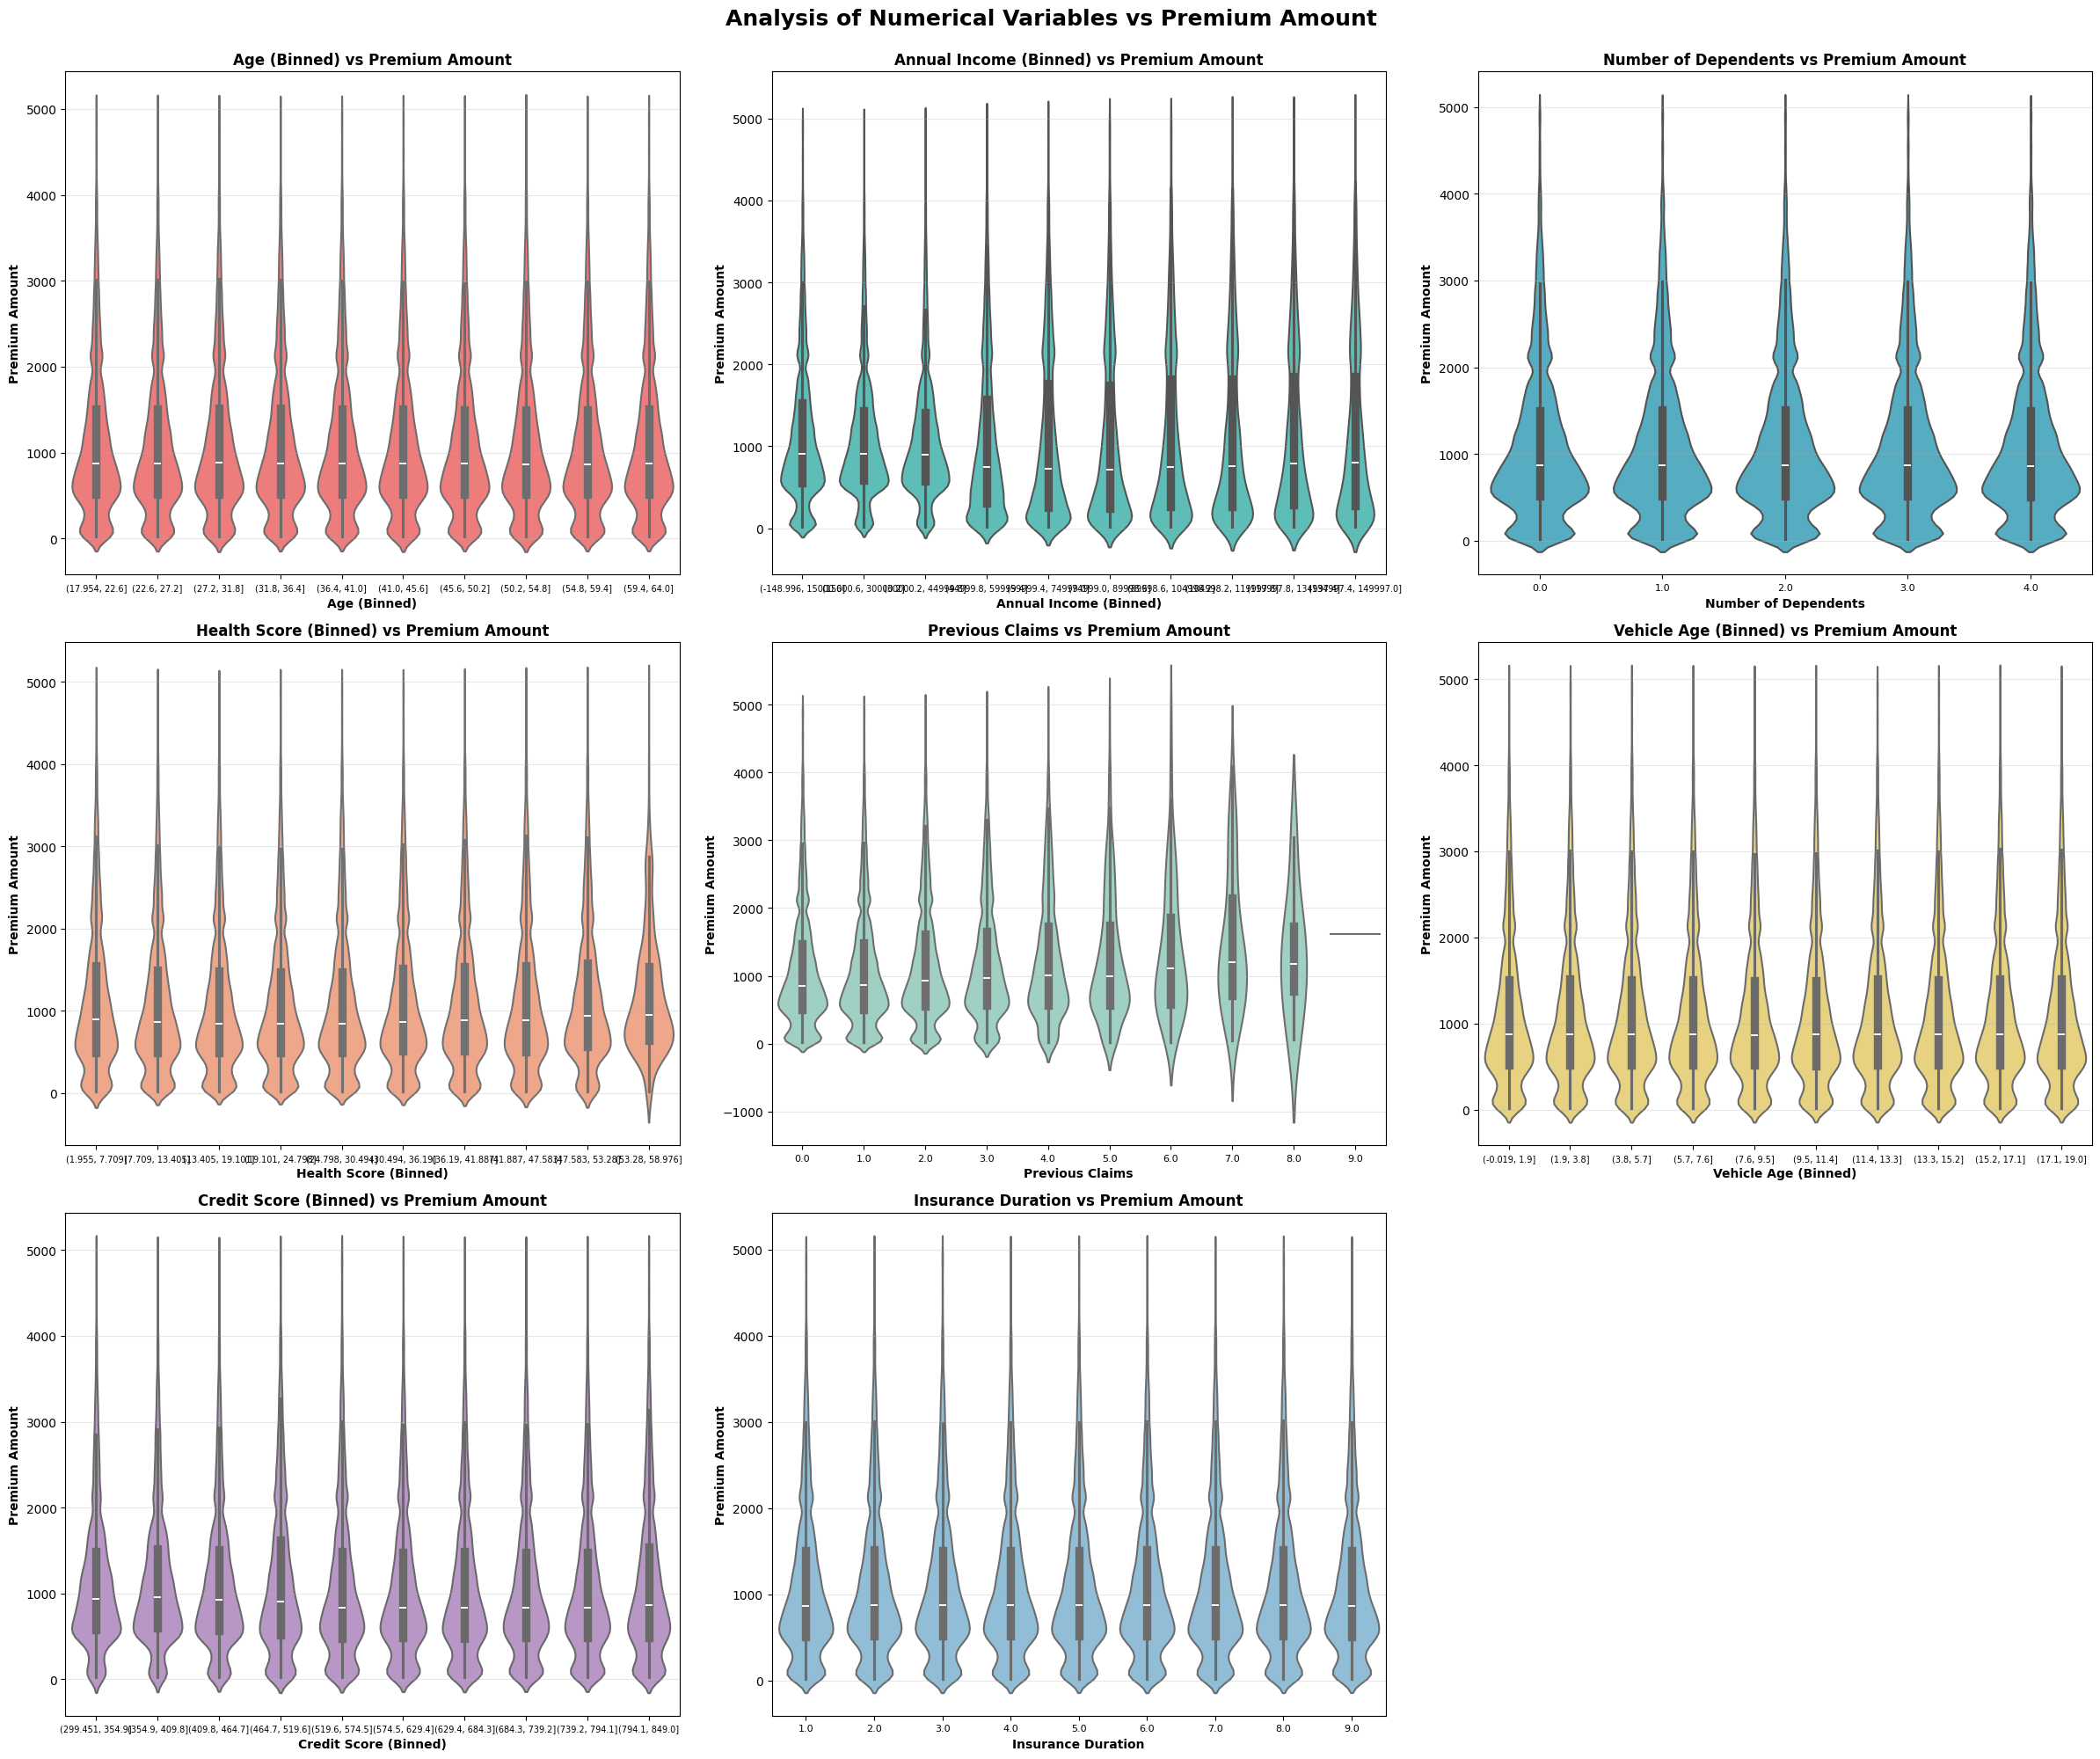

In [47]:
numerical_cols_for_analysis = df.select_dtypes(include=['int64', 'float64']).columns.drop(['id', 'Premium Amount']).tolist()

fig, axes = plt.subplots(3, 3, figsize=(24, 20))
axes = axes.flatten()

df_binned = df.copy()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', 
          '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B195']

for idx, col in enumerate(numerical_cols_for_analysis):
    if idx < len(axes):
        color = colors[idx % len(colors)]
        
        if df[col].nunique() > 10:
            df_binned[f'{col} (Binned)'] = pd.cut(df[col], bins=10)
            
            sns.violinplot(data=df_binned, x=f'{col} (Binned)', y='Premium Amount', 
                          ax=axes[idx], color=color, inner='box', linewidth=1.5)
            axes[idx].set_title(f'{col} (Binned) vs Premium Amount', 
                               fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(f'{col} (Binned)', fontweight='bold', fontsize=10)
            axes[idx].tick_params(axis='x', rotation=0, labelsize=7)
        else:
            sns.violinplot(data=df, x=col, y='Premium Amount', 
                          ax=axes[idx], color=color, inner='box', linewidth=1.5)
            axes[idx].set_title(f'{col} vs Premium Amount', 
                               fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col, fontweight='bold', fontsize=10)
            axes[idx].tick_params(axis='x', rotation=0, labelsize=8)
        
        axes[idx].set_ylabel('Premium Amount', fontweight='bold', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_cols_for_analysis), len(axes)):
    axes[idx].axis('off')
    
plt.suptitle('Analysis of Numerical Variables vs Premium Amount', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

## Categorical Features vs Premium Amount

/var/folders/rr/4y7qftxx1x3f53wj4d9l4m1h0000gn/T/ipykernel_12704/4171702998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=feature, y='Premium Amount', ax=axes[idx],
/var/folders/rr/4y7qftxx1x3f53wj4d9l4m1h0000gn/T/ipykernel_12704/4171702998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=feature, y='Premium Amount', ax=axes[idx],
/var/folders/rr/4y7qftxx1x3f53wj4d9l4m1h0000gn/T/ipykernel_12704/4171702998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=feature, y='Premium Amount

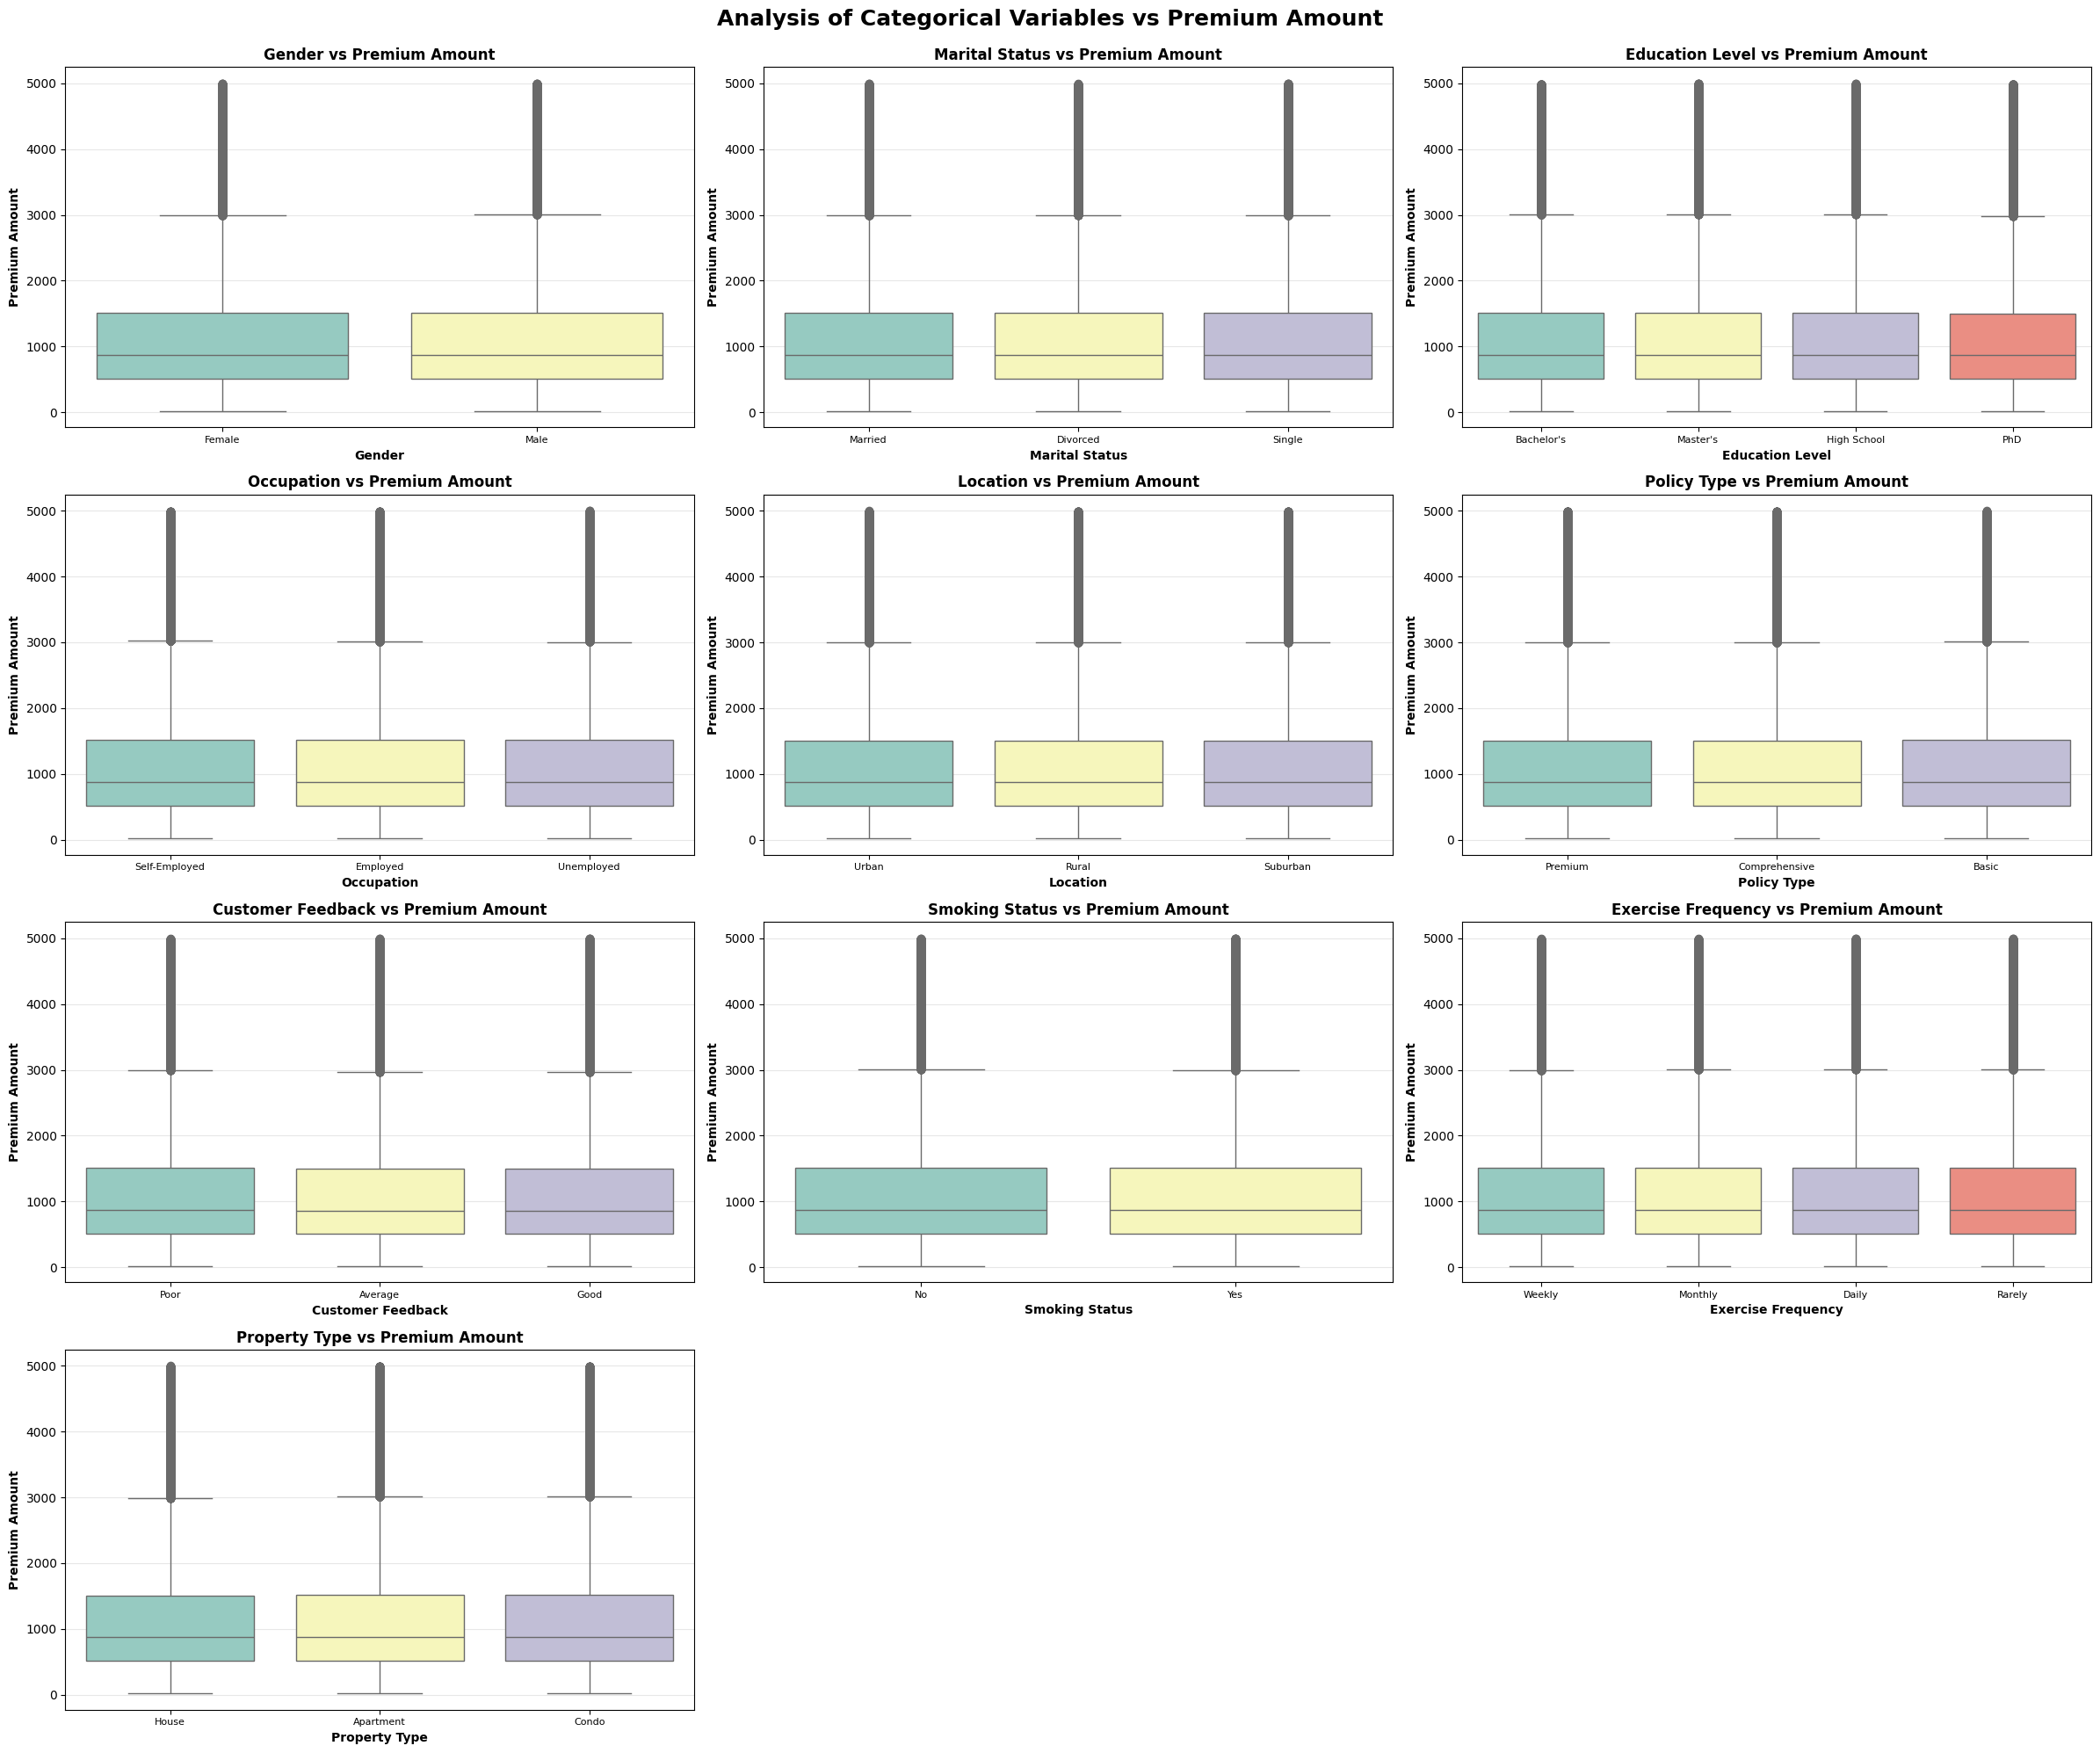

In [48]:
categorical_cols_for_analysis = df.select_dtypes(include=['object']).columns.drop(['Policy Start Date']).tolist()

fig, axes = plt.subplots(4, 3, figsize=(24, 20))
axes = axes.flatten()

for idx, feature in enumerate(categorical_cols_for_analysis):
    if idx < len(axes):
        if df[feature].nunique() > 10:
            top_categories = df[feature].value_counts().head(10).index
            plot_df = df[df[feature].isin(top_categories)]
            title_suffix = ' (Top 10)'
        else:
            plot_df = df
            title_suffix = ''
        
        sns.boxplot(data=plot_df, x=feature, y='Premium Amount', ax=axes[idx], 
                    palette='Set3')
        axes[idx].set_title(f'{feature} vs Premium Amount{title_suffix}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(feature, fontweight='bold', fontsize=10)
        axes[idx].set_ylabel('Premium Amount', fontweight='bold', fontsize=10)
        axes[idx].tick_params(axis='x', rotation=0, labelsize=8)
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplot
for i in range(len(categorical_cols_for_analysis), len(axes)):
    axes[i].axis('off')

plt.suptitle('Analysis of Categorical Variables vs Premium Amount', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Correlation Matrix

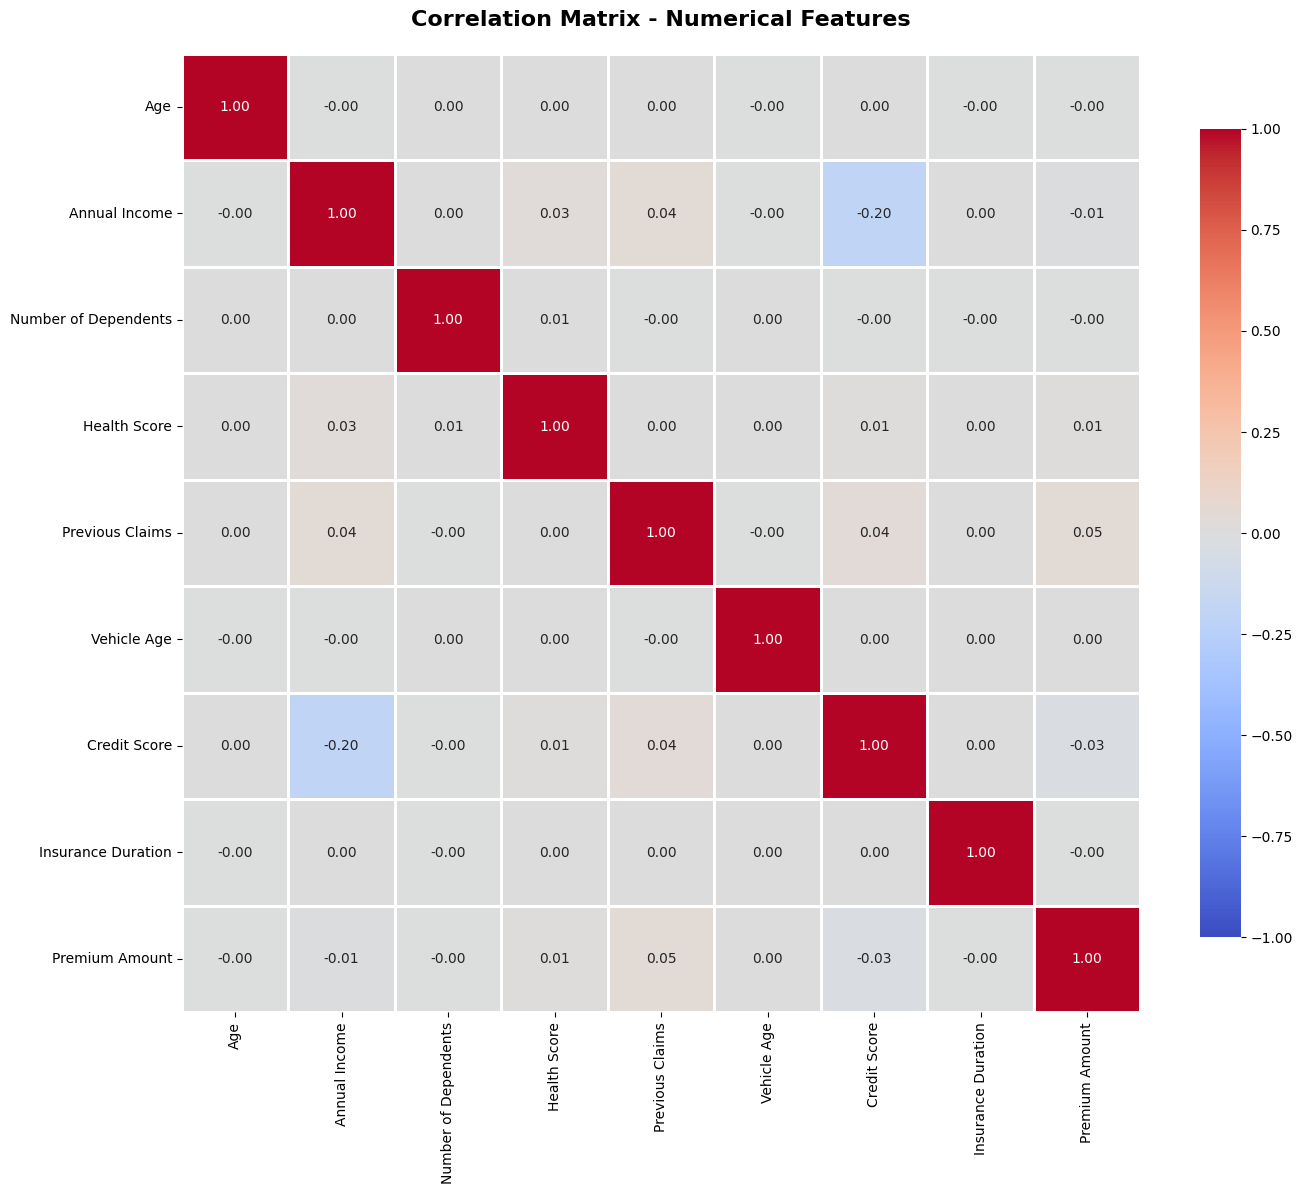

HIGHLY CORRELATED FEATURE PAIRS (|correlation| > 0.7)

No feature pairs with |correlation| > 0.7 found.


In [49]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['id'])
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("HIGHLY CORRELATED FEATURE PAIRS (|correlation| > 0.7)")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for var1, var2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1:30s} <-> {var2:30s} : {corr:7.3f}")
else:
    print("\nNo feature pairs with |correlation| > 0.7 found.")

## Outlier Detection Boxplots

In [53]:
# Detect outliers using the IQR method
numerical_cols = df.select_dtypes(include = ['number']).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | 
              (df[numerical_cols] > (Q3 + 1.5 * IQR))).sum()

print("Number of outliers (per column):\n", outliers)

Number of outliers (per column):
 id                          0
Age                         0
Annual Income           67132
Number of Dependents        0
Health Score                0
Previous Claims           369
Vehicle Age                 0
Credit Score                0
Insurance Duration          0
Premium Amount          49320
dtype: int64


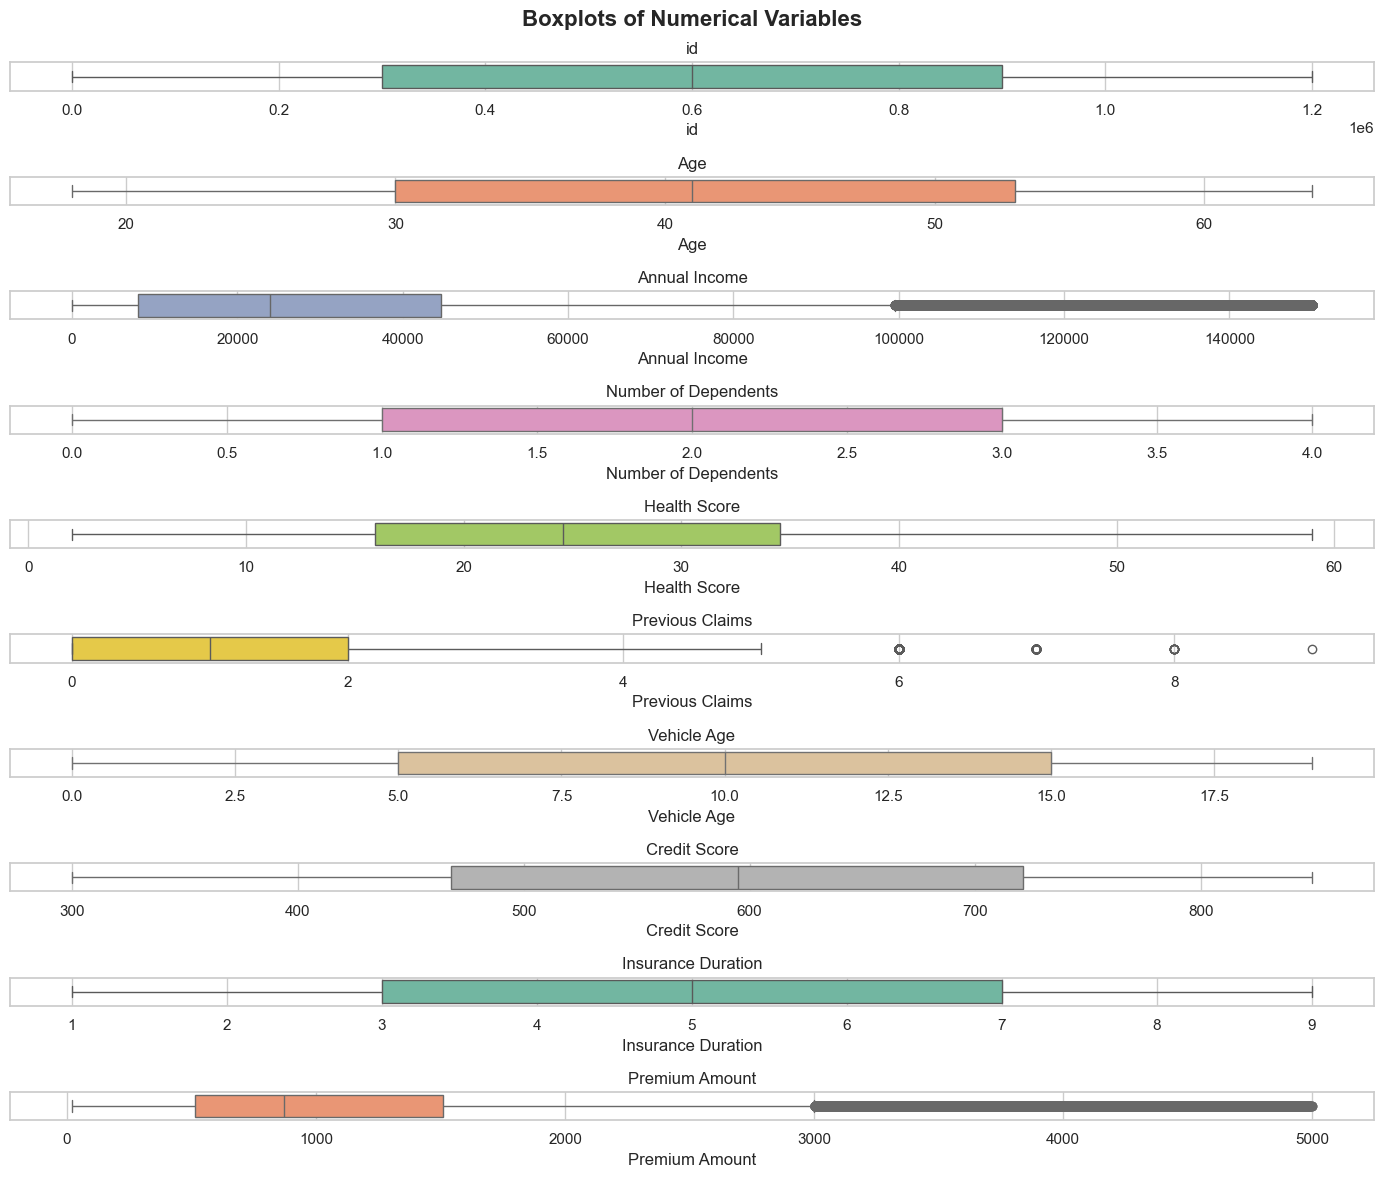

In [55]:
palette = sns.color_palette("Set2", n_colors=len(numerical_cols))

n = len(numerical_cols)

plt.figure(figsize=(14, n * 1.2))
plt.suptitle("Boxplots of Numerical Variables", fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n, 1, i)
    sns.boxplot(
        x=df[col],
        orient='h',
        color=palette[i - 1]
    )
    plt.title(col)
    plt.tight_layout()

plt.show()